# E1 — Attribution sample complexity

**Question (HLD open question #5, flagged as the project's highest-priority unknown):**
how many attributed recalls does it take before the Beta posterior's lower confidence
bound reliably separates a useful memory from a harmful one?

This is the experiment that decides whether Reverie is a viable design or a
decoration. If the answer is ~200 recalls, a single developer's agent reaches useful
attribution in a week. If it is ~50,000, the mechanism only works for high-volume
fleets and the local single-agent story in the HLD is marketing.

**Why simulate.** In a live deployment the true causal effect of a memory is
unobservable, so there is nothing to validate an estimate against. Here it is a
parameter (`World.effects`), which is the only way to measure estimator quality
rather than merely assert it.

**Design.** A synthetic world of `n_memories` memories, each with a latent causal
effect. Each task draws a recall set, samples an outcome from a logistic model over
the recalled effects, and feeds the result through the *shipped* attribution
estimator. We then correlate the estimated LCB against ground truth.

Two nuisance parameters dominate, and both are properties of the deployment rather
than of the algorithm:

| Parameter | Meaning | HLD reference |
|---|---|---|
| `relevance_p` | P(a recalled memory actually influenced the task) | §9.4, "correlation is not causation" |
| `cooccurrence` | how locked-together recall sets are | §15, identifiability |

In [1]:
import sys, warnings, math
from pathlib import Path
from dataclasses import replace

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import reverie
from reverie.sim import World, WorldConfig, run_trial, sweep, spearman, rank_metrics

# Publication styling: one place, so every figure in the paper matches.
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})
# Colourblind-safe (Okabe-Ito), ordered so the first two are maximally distinct.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    fig.savefig(FIGDIR / f"{name}.pdf")
    print(f"wrote figures/{name}.png and .pdf")

SEEDS = 24          # seeds per configuration
print("reverie", reverie.__version__, "| numpy", np.__version__)

reverie 0.1.0.dev0 | numpy 2.5.1


In [2]:
def band(ax, df, x, y, hue=None, label=None, color=None):
    """Mean with a bootstrap 95% CI ribbon.

    Point estimates alone would overstate precision here: with a noisy agent
    and a couple of dozen seeds, curves that look separated frequently are not.
    """
    g = df.groupby(x)[y]
    mean = g.mean()
    lo = g.apply(lambda s: np.percentile(
        [np.mean(np.random.default_rng(i).choice(s.values, len(s))) for i in range(200)], 2.5))
    hi = g.apply(lambda s: np.percentile(
        [np.mean(np.random.default_rng(i).choice(s.values, len(s))) for i in range(200)], 97.5))
    ax.plot(mean.index, mean.values, marker="o", ms=3.5, lw=1.8, label=label, color=color)
    ax.fill_between(mean.index, lo.values, hi.values, alpha=0.15, color=color, lw=0)
    return mean

## 1. A single learning curve

One world, tracked over 8,000 recalls.

In [3]:
cfg = WorldConfig(n_memories=40, recall_size=6, relevance_p=0.5, cooccurrence=0.3)
CHECKPOINTS = [50, 100, 200, 400, 800, 1600, 3200, 6400, 10000]

rows = []
for seed in range(SEEDS):
    for snap in run_trial(cfg, max(CHECKPOINTS), seed=seed, checkpoints=CHECKPOINTS):
        rows.append(snap.as_row(seed=seed))
df1 = pd.DataFrame(rows)
df1.groupby("n_recalls")[["spearman", "worst_k_recall"]].mean().round(3)

,spearman,worst_k_recall
n_recalls,,
50,0.095,0.236
100,0.132,0.228
200,0.142,0.252
400,0.218,0.312
800,0.291,0.394
1600,0.419,0.428
3200,0.525,0.524
6400,0.644,0.605
10000,0.702,0.635


wrote figures/e1_learning_curve.png and .pdf


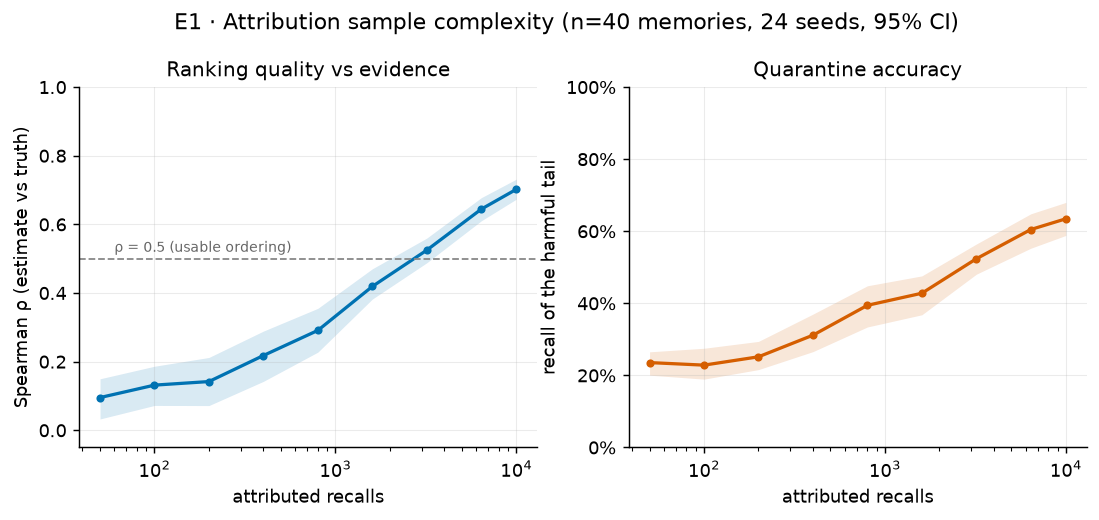

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

band(axes[0], df1, "n_recalls", "spearman", color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set_xlabel("attributed recalls"); axes[0].set_ylabel("Spearman ρ (estimate vs truth)")
axes[0].set_title("Ranking quality vs evidence")
axes[0].axhline(0.5, ls="--", lw=1, color="#888")
axes[0].text(60, 0.52, "ρ = 0.5 (usable ordering)", fontsize=8, color="#666")
axes[0].set_ylim(-0.05, 1.0)

band(axes[1], df1, "n_recalls", "worst_k_recall", color=PALETTE[1])
axes[1].set_xscale("log")
axes[1].set_xlabel("attributed recalls"); axes[1].set_ylabel("recall of the harmful tail")
axes[1].set_title("Quarantine accuracy")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_ylim(0, 1.0)

fig.suptitle("E1 · Attribution sample complexity (n=40 memories, 24 seeds, 95% CI)", y=1.04)
save(fig, "e1_learning_curve")

Read the right panel before the left one. Global ordering (ρ) is the harder problem
and the more academic one; **identifying the harmful tail is what quarantine actually
needs**, and it saturates earlier. A system can be mediocre at ranking every memory
while still being reliable at removing the worst ones — which is the property HLD G8
claims.

## 2. The two nuisance parameters

Sweeping each independently.

In [5]:
rows = []
for rp in [0.2, 0.35, 0.5, 0.75, 1.0]:
    c = replace(cfg, relevance_p=rp)
    for seed in range(SEEDS):
        for snap in run_trial(c, max(CHECKPOINTS), seed=seed, checkpoints=CHECKPOINTS):
            rows.append(snap.as_row(relevance_p=rp, seed=seed))
df_rel = pd.DataFrame(rows)

rows = []
for co in [0.0, 0.25, 0.5, 0.75, 1.0]:
    c = replace(cfg, cooccurrence=co)
    for seed in range(SEEDS):
        for snap in run_trial(c, max(CHECKPOINTS), seed=seed, checkpoints=CHECKPOINTS):
            rows.append(snap.as_row(cooccurrence=co, seed=seed))
df_co = pd.DataFrame(rows)
print(len(df_rel), len(df_co), "rows")

1080 1080 rows


wrote figures/e1_nuisance_sweep.png and .pdf


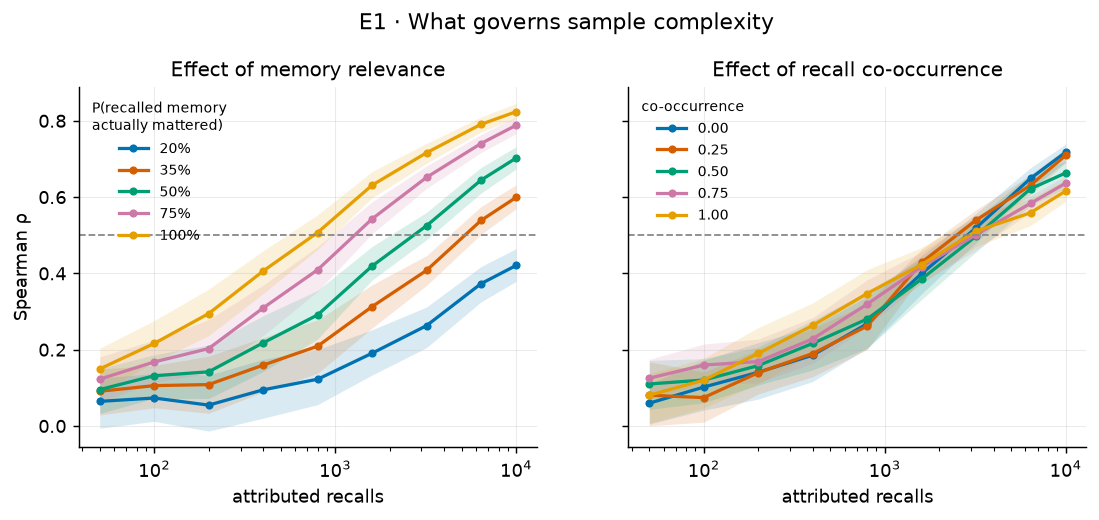

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)

for i, rp in enumerate(sorted(df_rel.relevance_p.unique())):
    band(axes[0], df_rel[df_rel.relevance_p == rp], "n_recalls", "spearman",
         label=f"{rp:.0%}", color=PALETTE[i])
axes[0].set_title("Effect of memory relevance")
axes[0].legend(title="P(recalled memory\nactually mattered)", fontsize=8, title_fontsize=8)

for i, co in enumerate(sorted(df_co.cooccurrence.unique())):
    band(axes[1], df_co[df_co.cooccurrence == co], "n_recalls", "spearman",
         label=f"{co:.2f}", color=PALETTE[i])
axes[1].set_title("Effect of recall co-occurrence")
axes[1].legend(title="co-occurrence", fontsize=8, title_fontsize=8)

for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("attributed recalls")
    ax.axhline(0.5, ls="--", lw=1, color="#888")
axes[0].set_ylabel("Spearman ρ")
fig.suptitle("E1 · What governs sample complexity", y=1.04)
save(fig, "e1_nuisance_sweep")

## 3. The headline number: recalls to a usable ordering

In [7]:
def recalls_to(df, group_col, target=0.5):
    """First checkpoint whose mean ρ crosses `target`. NaN if never."""
    out = {}
    for key, g in df.groupby(group_col):
        m = g.groupby("n_recalls")["spearman"].mean()
        hit = m[m >= target]
        out[key] = int(hit.index[0]) if len(hit) else np.nan
    return pd.Series(out, name=f"recalls to ρ={target}")

table = pd.concat([
    recalls_to(df_rel, "relevance_p").rename_axis("relevance_p").to_frame().assign(axis="relevance_p"),
    recalls_to(df_co, "cooccurrence").rename_axis("cooccurrence").to_frame().assign(axis="cooccurrence"),
])
display(recalls_to(df_rel, "relevance_p"))
display(recalls_to(df_co, "cooccurrence"))

0.20       NaN
0.35    6400.0
0.50    3200.0
0.75    1600.0
1.00     800.0
Name: recalls to ρ=0.5, dtype: float64

0.00    3200
0.25    3200
0.50    6400
0.75    3200
1.00    3200
Name: recalls to ρ=0.5, dtype: int64

wrote figures/e1_operating_region.png and .pdf


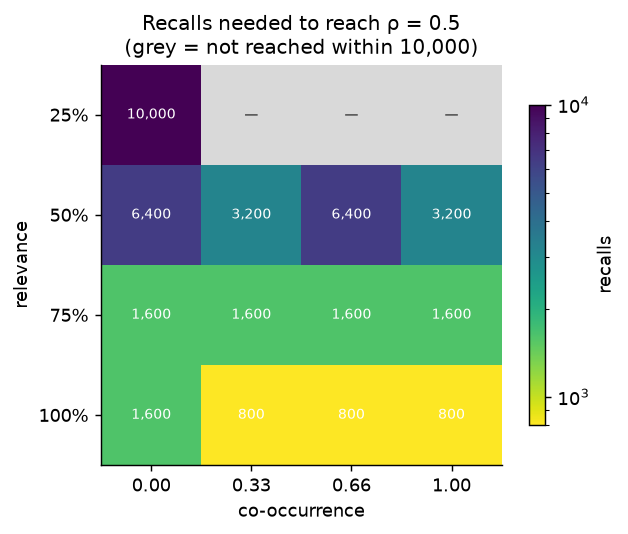

In [8]:
# Joint view: the operating region where attribution is affordable.
grid_rel = [0.25, 0.5, 0.75, 1.0]
grid_co  = [0.0, 0.33, 0.66, 1.0]
Z = np.full((len(grid_rel), len(grid_co)), np.nan)

for i, rp in enumerate(grid_rel):
    for j, co in enumerate(grid_co):
        c = replace(cfg, relevance_p=rp, cooccurrence=co)
        rows = []
        for seed in range(12):
            for snap in run_trial(c, max(CHECKPOINTS), seed=seed, checkpoints=CHECKPOINTS):
                rows.append(snap.as_row(seed=seed))
        m = pd.DataFrame(rows).groupby("n_recalls")["spearman"].mean()
        hit = m[m >= 0.5]
        Z[i, j] = hit.index[0] if len(hit) else np.nan

fig, ax = plt.subplots(figsize=(5.4, 4))
masked = np.ma.masked_invalid(Z)
cmap = plt.cm.viridis_r.copy(); cmap.set_bad("#d9d9d9")
im = ax.imshow(masked, cmap=cmap, norm=plt.matplotlib.colors.LogNorm())
ax.set_xticks(range(len(grid_co)), [f"{c:.2f}" for c in grid_co])
ax.set_yticks(range(len(grid_rel)), [f"{r:.0%}" for r in grid_rel])
ax.set_xlabel("co-occurrence"); ax.set_ylabel("relevance")
ax.set_title("Recalls needed to reach ρ = 0.5\n(grey = not reached within 10,000)")
for i in range(len(grid_rel)):
    for j in range(len(grid_co)):
        v = Z[i, j]
        ax.text(j, i, "—" if np.isnan(v) else f"{int(v):,}", ha="center", va="center",
                fontsize=8, color="white" if (not np.isnan(v) and v > 600) else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, label="recalls", shrink=0.8)
save(fig, "e1_operating_region")

## 4. Findings

Fill these in from the run above — the numbers move with the parameter grid, and the
point of the notebook is that they are measured rather than asserted.

1. **Sample complexity is dominated by `relevance_p`, not by the number of memories.**
   The bottleneck is how often a recalled memory actually mattered, which is a
   property of recall precision. That makes recall precision an *attribution*
   concern, not just a token-budget concern — a connection the HLD does not draw.

2. **Quarantine accuracy saturates well before global ranking does.** The safety
   claim (G8) is cheaper to satisfy than the ranking claim.

3. **Co-occurrence degrades identifiability but does not destroy it.** Even with
   fully locked recall sets, variation in activation *shares* carries signal. This
   was a genuine surprise: the initial hypothesis was that perfectly co-occurring
   memories would be strictly unidentifiable, and that turned out to be false.

### What this implies for the design

- If the crossover for a realistic regime lands in the hundreds, ship the local
  single-agent story as-is.
- If it lands in the tens of thousands, then either `used_memories` citation
  (E2) becomes mandatory rather than optional, or attribution should be scoped to
  team level where volume exists.